In [1]:
#Install & Import Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud
import re
import warnings

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

In [2]:
# #Load Cleaned Resume Dataset ===
# df = pd.read_csv('/content/resume_data_cleaned.csv')  # Upload this to Colab
# print("✅ Dataset loaded:", df.shape)
# print("Unique categories:", df['Category'].nunique())


In [4]:
df = pd.read_parquet('data/processed/resume_data_cleaned.parquet')
print("✅ Dataset loaded:", df.shape)
print("Unique categories:", df['Category'].nunique())


✅ Dataset loaded: (12084, 2)
Unique categories: 43


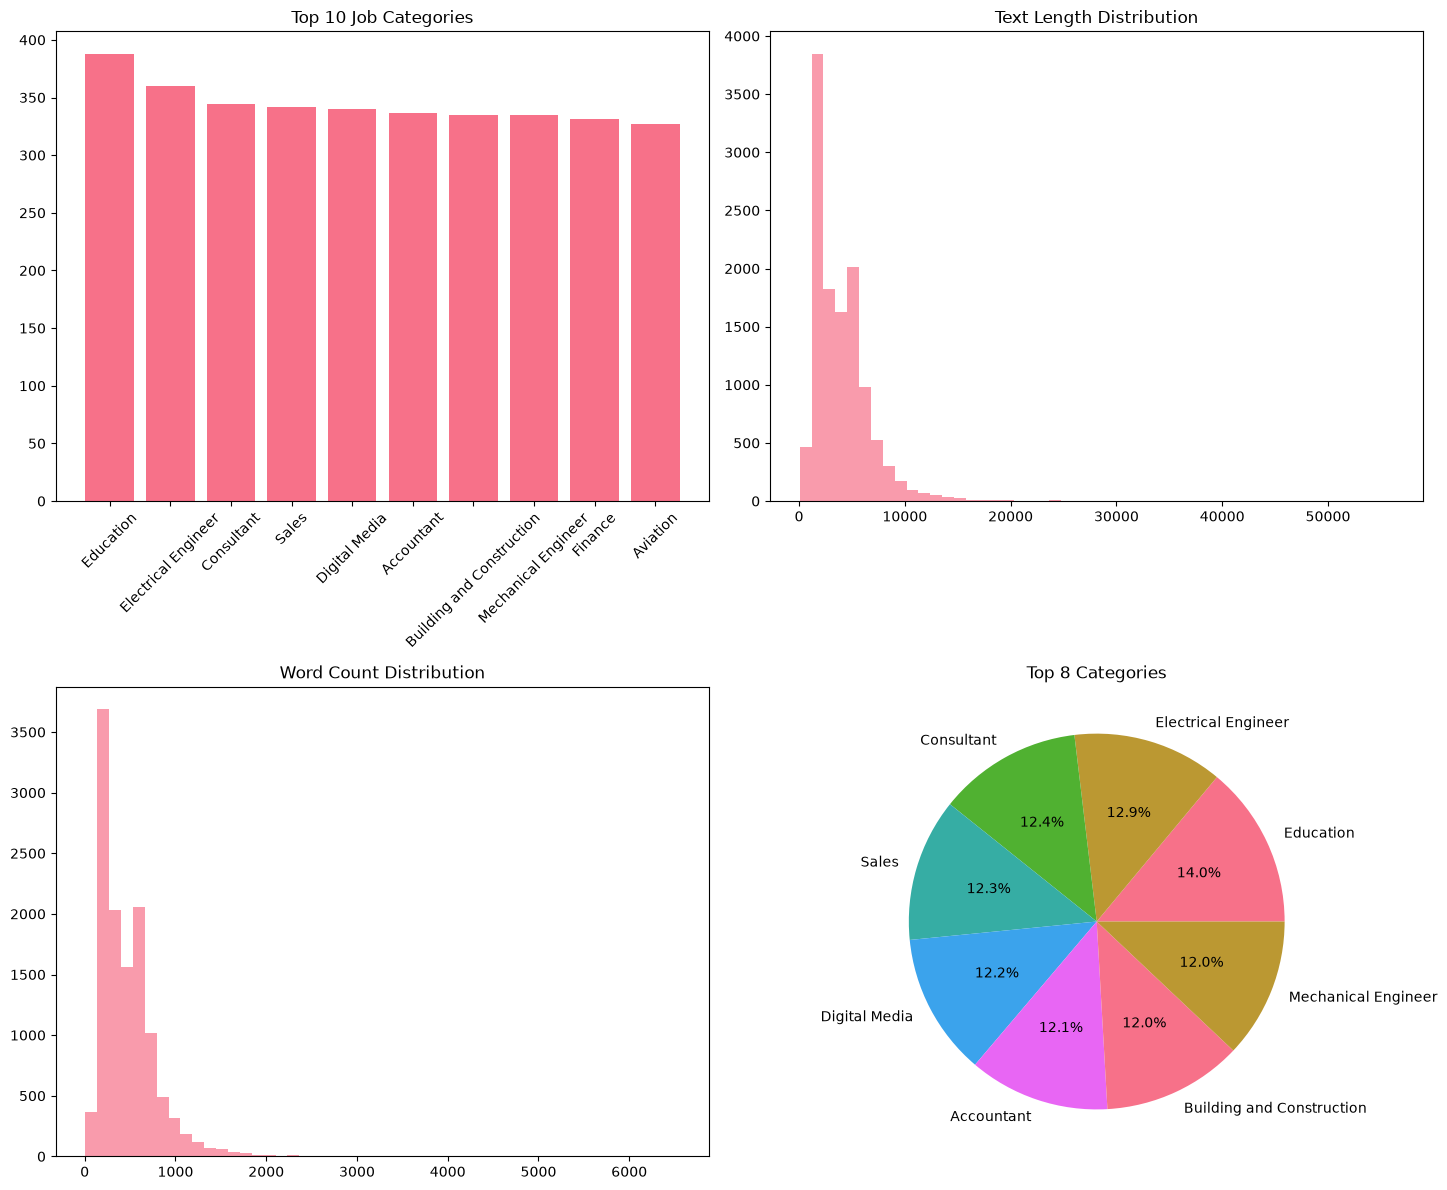

In [5]:
#Exploratory Data Analysis (EDA) ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

category_counts = df['Category'].value_counts()

axes[0, 0].bar(category_counts.head(10).index, category_counts.head(10).values)
axes[0, 0].set_title('Top 10 Job Categories')
axes[0, 0].tick_params(axis='x', rotation=45)

text_lengths = df['Text'].str.len()
axes[0, 1].hist(text_lengths, bins=50, alpha=0.7)
axes[0, 1].set_title('Text Length Distribution')

word_counts = df['Text'].str.split().str.len()
axes[1, 0].hist(word_counts, bins=50, alpha=0.7)
axes[1, 0].set_title('Word Count Distribution')

top_categories = category_counts.head(8)
axes[1, 1].pie(top_categories.values, labels=top_categories.index, autopct='%1.1f%%')
axes[1, 1].set_title('Top 8 Categories')

plt.tight_layout()
plt.show()


In [6]:
#Extract NLP-Based Features
def extract_features(text):
    features = {}
    features['char_count'] = len(text)
    features['word_count'] = len(text.split())
    features['sentence_count'] = len(re.findall(r'[.!?]+', text))
    features['avg_word_length'] = np.mean([len(w) for w in text.split()]) if text.split() else 0

    education = ['bachelor', 'master', 'phd', 'university', 'college', 'mba', 'btech', 'mtech']
    experience = ['experience', 'worked', 'years', 'months', 'project', 'developed', 'managed']
    skills = ['python', 'java', 'sql', 'react', 'nodejs', 'html', 'css', 'mysql']
    certs = ['certified', 'aws', 'azure', 'oracle', 'certificate']
    roles = ['senior', 'lead', 'manager', 'architect', 'consultant']

    features['education_mentions'] = sum(k in text.lower() for k in education)
    features['experience_mentions'] = sum(k in text.lower() for k in experience)
    features['skill_mentions'] = sum(k in text.lower() for k in skills)
    features['cert_mentions'] = sum(k in text.lower() for k in certs)
    features['prof_level_mentions'] = sum(k in text.lower() for k in roles)

    return features

feature_df = df['Text'].apply(extract_features).apply(pd.Series)
df_features = pd.concat([df, feature_df], axis=1)
print("✅ Feature engineering complete!")


✅ Feature engineering complete!


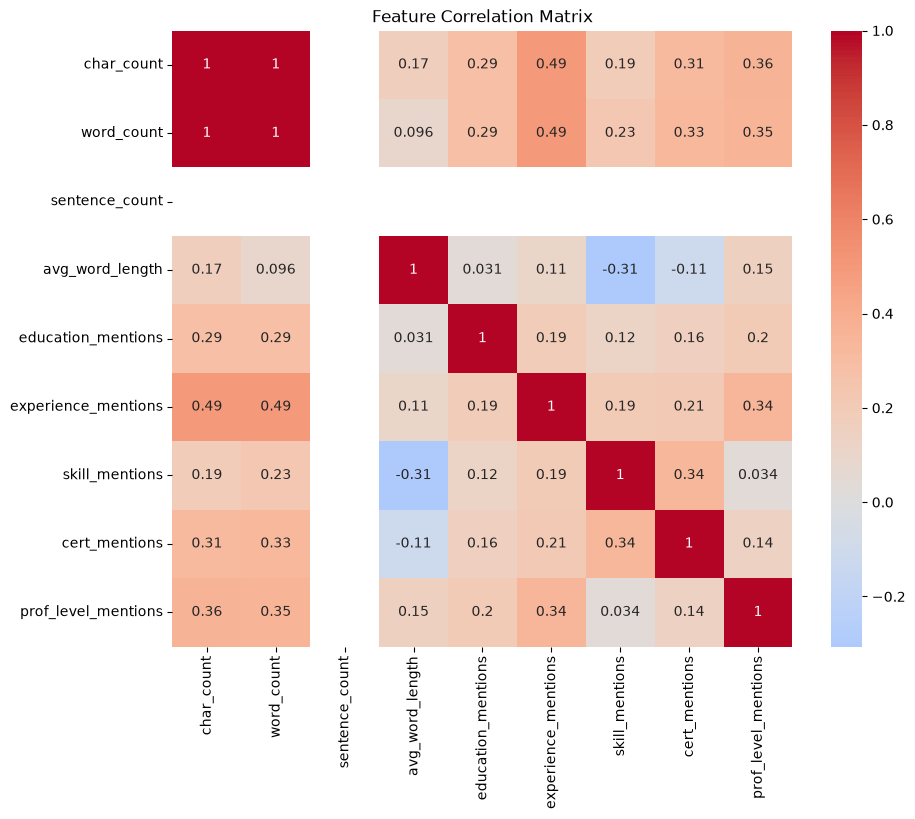

In [7]:
#Correlation Heatmap ===
plt.figure(figsize=(10, 8))
sns.heatmap(feature_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()


In [8]:
#Train-Test Split & Label Encoding ===
X = df['Text']
y = df['Category']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("✅ Data split complete")
print("Train size:", len(X_train), "| Test size:", len(X_test))


✅ Data split complete
Train size: 9667 | Test size: 2417


In [9]:
# Vectorize Text using TF-IDF and CountVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.8
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

count_vectorizer = CountVectorizer(
    max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.8
)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("✅ TF-IDF Shape:", X_train_tfidf.shape)
print("✅ CountVec Shape:", X_train_count.shape)


✅ TF-IDF Shape: (9667, 5000)
✅ CountVec Shape: (9667, 5000)


In [10]:
#Show Top TF-IDF Features ===
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_scores = X_train_tfidf.mean(axis=0).A1
top_features = sorted(zip(feature_names, mean_scores), key=lambda x: x[1], reverse=True)[:20]

print("🔝 Top TF-IDF Features:")
for feat, score in top_features:
    print(f"{feat}: {score:.4f}")


🔝 Top TF-IDF Features:
management: 0.0370
data: 0.0347
business: 0.0330
customer: 0.0330
sales: 0.0313
project: 0.0302
design: 0.0275
team: 0.0266
development: 0.0258
new: 0.0254
service: 0.0238
using: 0.0232
work: 0.0231
financial: 0.0208
systems: 0.0202
customers: 0.0198
support: 0.0197
state: 0.0194
training: 0.0191
software: 0.0191


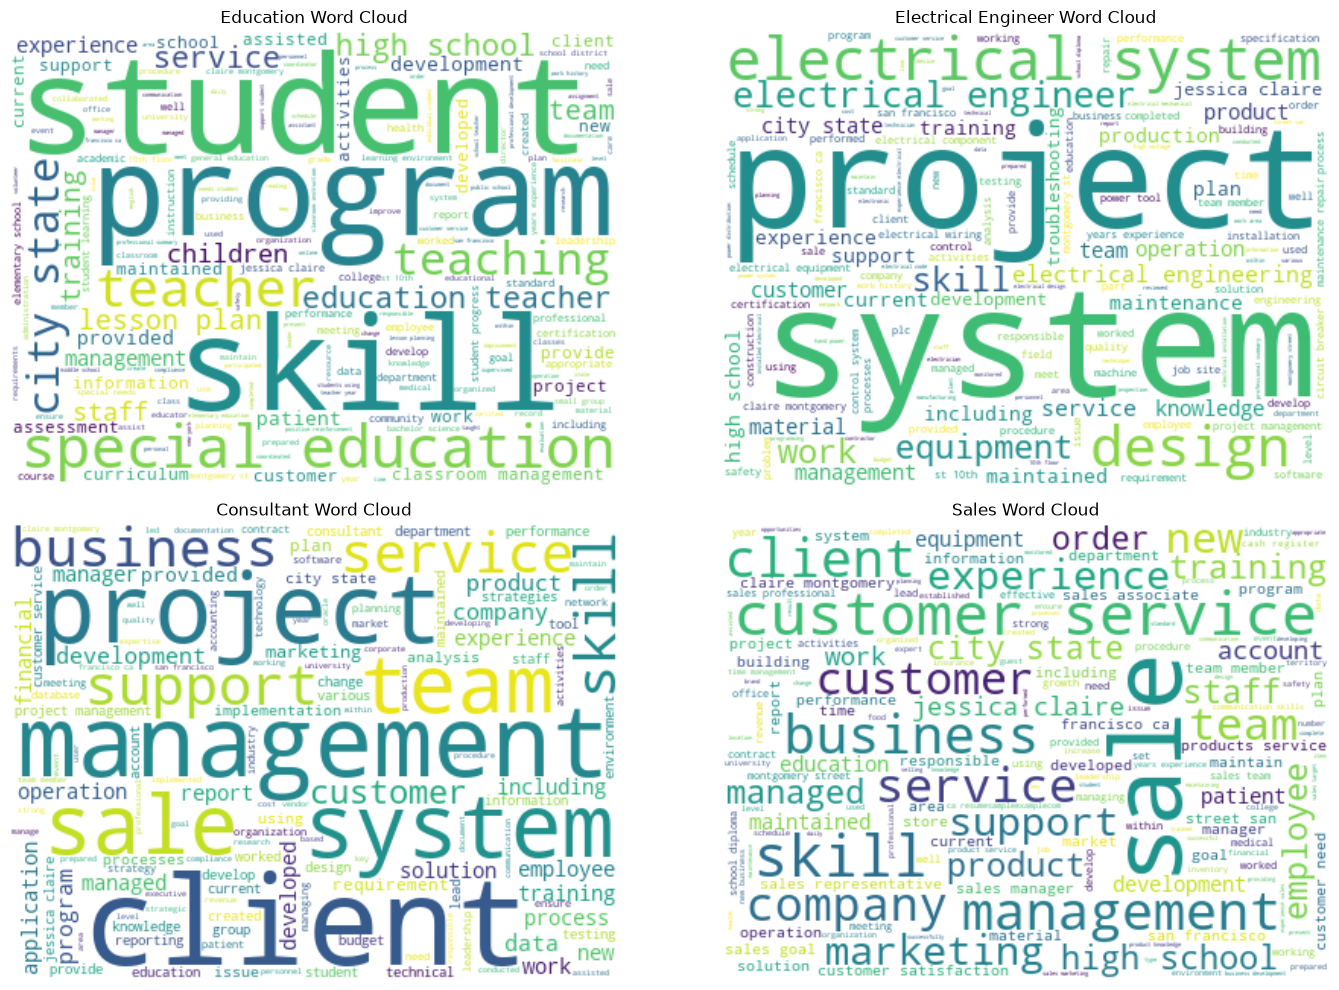

In [11]:
#Word Clouds for Top Categories ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

top_cats = df['Category'].value_counts().head(4).index
for i, cat in enumerate(top_cats):
    text = ' '.join(df[df['Category'] == cat]['Text'].values)
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{cat} Word Cloud')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [12]:
#Save Vectorizers and Arrays ===
import joblib, os

os.makedirs('models', exist_ok=True)
os.makedirs('data/arrays', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(count_vectorizer, 'models/count_vectorizer.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

np.save('data/arrays/X_train_tfidf.npy', X_train_tfidf.toarray())
np.save('data/arrays/X_test_tfidf.npy', X_test_tfidf.toarray())
np.save('data/arrays/X_train_count.npy', X_train_count.toarray())
np.save('data/arrays/X_test_count.npy', X_test_count.toarray())
np.save('data/arrays/y_train.npy', y_train)
np.save('data/arrays/y_test.npy', y_test)

df_features.to_parquet('data/processed/resume_data_with_features.parquet')

print("✅ Saved all vectorizers, arrays, and enhanced dataset.")


✅ Saved all vectorizers, arrays, and enhanced dataset.


In [13]:
#----------------------------------------------MODEL Training------------------------------------------------------------

In [14]:
# Import Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import joblib
import warnings
warnings.filterwarnings('ignore')


In [15]:
#Load TF-IDF Vectors and Encoders ===
print("Loading preprocessed vectorizers and dataset...")

tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
count_vectorizer = joblib.load('models/count_vectorizer.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')

X_train_tfidf = np.load('data/arrays/X_train_tfidf.npy')
X_test_tfidf = np.load('data/arrays/X_test_tfidf.npy')
y_train = np.load('data/arrays/y_train.npy')
y_test = np.load('data/arrays/y_test.npy')

print("✅ Data loaded:", X_train_tfidf.shape)
print("🔢 Classes:", len(label_encoder.classes_))


Loading preprocessed vectorizers and dataset...
✅ Data loaded: (9667, 5000)
🔢 Classes: 43


In [16]:
# Define Evaluation Function ===
results = {}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n🔍 Evaluating: {model_name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    print(f"✅ Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"📉 Cross-Val Score: {cv.mean():.4f} ± {cv.std()*2:.4f}")

    results[model_name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'cv_score': cv.mean(), 'cv_std': cv.std(), 'model': model, 'predictions': y_pred
    }
    return y_pred


In [17]:
# Train Baseline Models
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    evaluate_model(model, X_train_tfidf, X_test_tfidf, y_train, y_test, name)



🔍 Evaluating: Naive Bayes
✅ Accuracy: 0.6880 | Precision: 0.6970 | Recall: 0.6880 | F1: 0.6824
📉 Cross-Val Score: 0.6975 ± 0.0190

🔍 Evaluating: Logistic Regression
✅ Accuracy: 0.7803 | Precision: 0.7882 | Recall: 0.7803 | F1: 0.7796
📉 Cross-Val Score: 0.7866 ± 0.0218

🔍 Evaluating: SVM
✅ Accuracy: 0.7758 | Precision: 0.7986 | Recall: 0.7758 | F1: 0.7807
📉 Cross-Val Score: 0.7789 ± 0.0223

🔍 Evaluating: Random Forest
✅ Accuracy: 0.8171 | Precision: 0.8211 | Recall: 0.8171 | F1: 0.8115
📉 Cross-Val Score: 0.8053 ± 0.0172

🔍 Evaluating: KNN
✅ Accuracy: 0.6889 | Precision: 0.6830 | Recall: 0.6889 | F1: 0.6768
📉 Cross-Val Score: 0.6866 ± 0.0152


In [18]:
#Model Comparison Summary
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'CV Score': [results[m]['cv_score'] for m in results]
}).sort_values('Accuracy', ascending=False)

print("\n📊 Model Comparison:")
print(comparison_df.round(4))



📊 Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  CV Score
3        Random Forest    0.8171     0.8211  0.8171    0.8115    0.8053
1  Logistic Regression    0.7803     0.7882  0.7803    0.7796    0.7866
2                  SVM    0.7758     0.7986  0.7758    0.7807    0.7789
4                  KNN    0.6889     0.6830  0.6889    0.6768    0.6866
0          Naive Bayes    0.6880     0.6970  0.6880    0.6824    0.6975


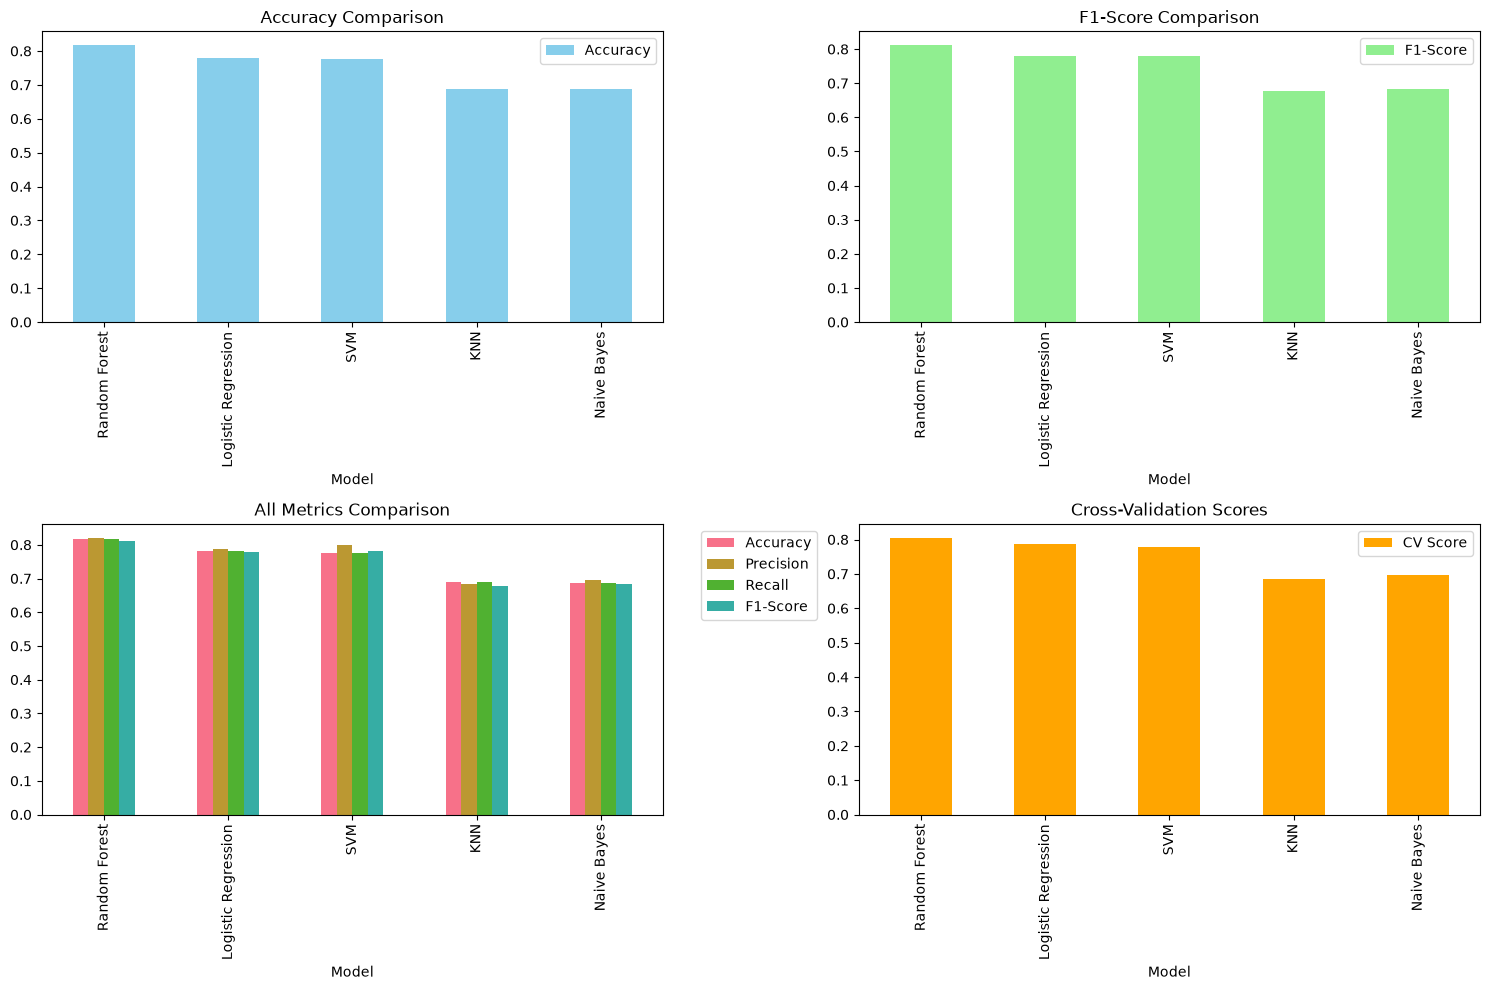

In [19]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
comparison_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Accuracy Comparison')

# F1-Score
comparison_df.plot(x='Model', y='F1-Score', kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('F1-Score Comparison')

# All metrics
metrics_df = comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Model')
metrics_df.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('All Metrics Comparison')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# CV Scores
comparison_df.plot(x='Model', y='CV Score', kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Cross-Validation Scores')

plt.tight_layout()
plt.show()


In [20]:
#Save Best Model
import os
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
joblib.dump(best_model, f'models/best_model_{best_model_name.lower().replace(" ", "_")}.pkl')
comparison_df.to_csv("results/model_comparison_results.csv", index=False)

print(f"🏆 Saved best model: models/best_model_{best_model_name.lower().replace(' ', '_')}.pkl")
print("📄 Results: results/model_comparison_results.csv")


🏆 Saved best model: best_model_random_forest.pkl
📄 Results: model_comparison_results.csv



📋 Classification Report - Random Forest
                           precision    recall  f1-score   support

               Accountant       0.77      0.97      0.86        67
                 Advocate       0.75      0.93      0.83        56
              Agriculture       0.89      0.89      0.89        45
                  Apparel       0.89      0.86      0.87        63
             Architecture       0.91      0.66      0.76        61
                     Arts       0.85      0.58      0.69        50
               Automobile       0.82      0.77      0.79        60
                 Aviation       0.83      0.95      0.89        65
                      BPO       0.86      0.31      0.45        39
                  Banking       0.87      0.93      0.90        58
               Blockchain       1.00      0.89      0.94         9
Building and Construction       0.71      0.84      0.77        67
        Business Analysis       0.86      0.89      0.87        62
           Civil Eng

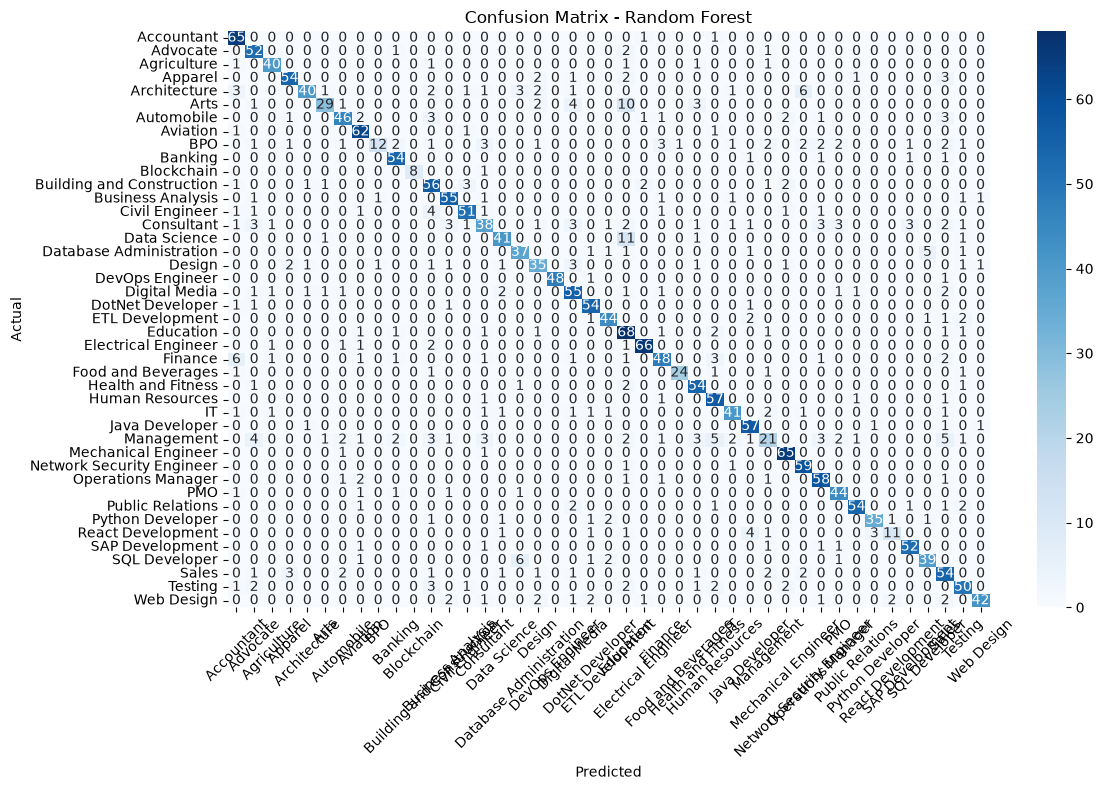

In [21]:
# Confusion Matrix for Best Model
from sklearn.metrics import classification_report, confusion_matrix

y_pred = results[best_model_name]['predictions']
print(f"\n📋 Classification Report - {best_model_name}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
#Summary
print("=" * 60)
print("SUMMARY & NEXT STEPS")
print("=" * 60)
print(f"🏆 Best Model: {best_model_name}")
print(f"🎯 Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"📋 Classes: {len(label_encoder.classes_)}")

SUMMARY & NEXT STEPS
🏆 Best Model: Random Forest
🎯 Accuracy: 0.8171
📋 Classes: 43


In [23]:
#----------------------------------tf-idf + cosine simmilarity-----------------

In [24]:
#Load TF-IDF Vectorizer and Resume Dataset ===
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity

# Load the TF-IDF vectorizer (must match what was used during resume processing)
tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')

# Load the preprocessed resumes (cleaned text)
df = pd.read_parquet('data/processed/resume_data_with_features.parquet')
print("✅ Dataset loaded:", df.shape)

# Show sample columns
print(df.columns)
print(df[['Text', 'Category']].head())


✅ Dataset loaded: (12143, 11)
Index(['Category', 'Text', 'char_count', 'word_count', 'sentence_count',
       'avg_word_length', 'education_mentions', 'experience_mentions',
       'skill_mentions', 'cert_mentions', 'prof_level_mentions'],
      dtype='str')
                                                Text    Category
0  EDUCATION OMBA - Executive Leadership Universi...  Accountant
1  HOWARD GERRARD Accountant Deyjob.com, Birmingh...  Accountant
2  Kevin Frank SENIOR ACCOUNTANT EMAIL PHONE Chic...  Accountant
3  Place of birth Nationality Olivia Ogilvy, Acco...  Accountant
4  Stephen Greet, CPA Senior Accountant Through m...  Accountant


In [25]:
# Vectorize Resume Text using TF-IDF ===
# Make sure 'Text' column is the cleaned version used earlier
resume_texts = df['Text'].tolist()
resume_vectors = tfidf_vectorizer.transform(resume_texts)

print("✅ Resume TF-IDF vectors shape:", resume_vectors.shape)


✅ Resume TF-IDF vectors shape: (12143, 5000)


In [26]:
# Input or Paste a Job Description ===
job_description = """
We are looking for a skilled Data Scientist with experience in Python, machine learning,
data analysis, and statistical modeling. Familiarity with TensorFlow or PyTorch is a plus.
"""

# Vectorize the JD
jd_vector = tfidf_vectorizer.transform([job_description])
print("✅ Job description vectorized")


✅ Job description vectorized


In [27]:
# Compute Cosine Similarity
similarity_scores = cosine_similarity(jd_vector, resume_vectors).flatten()

# Add similarity scores to the dataframe
df['SimilarityScore'] = similarity_scores

# Show top 10 matching resumes
top_matches = df.sort_values(by='SimilarityScore', ascending=False).head(10)
top_matches[['Text', 'Category', 'SimilarityScore']]


,Text,Category,SimilarityScore
3543,Email: EMAIL Phone No.: +223 948 420 Location:...,Data Science,0.526773
3522,CHARLOTTE MAY Senior Data Scientist CAP DASCA ...,Data Science,0.483260
804,"Malik Rabb Seattle, WA. PHONE EMAIL SUMMARY Da...",Data Science,0.475717
823,Robert Smith Data Scientist Trainee CONTACT DE...,Data Science,0.468066
3551,Data Scientist Intern ROBERT SMITH Phone: (123...,Data Science,0.467528
3539,Personal Info PHONE EMAIL in linkedin.com/in/t...,Data Science,0.462505
803,Microsoft and Google certified data scientist ...,Data Science,0.460957
812,"Trisha Stamm Data Scientist, Microsoft Certifi...",Data Science,0.460957
817,"Trisha Stamm Data Scientist, Microsoft Certifi...",Data Science,0.460957
3516,"Trisha Stamm Data Scientist, Microsoft Certifi...",Data Science,0.448254


In [28]:
#  Preview Top Matches
for i, row in top_matches.iterrows():
    print(f"\n🎯 Score: {row['SimilarityScore']:.4f} | 🏷️ Category: {row['Category']}")
    print("-" * 80)
    print(row['Text'][:500])  # Print first 500 chars of resume


🎯 Score: 0.5268 | 🏷️ Category: Data Science
--------------------------------------------------------------------------------
Email: EMAIL Phone No.: +223 948 420 Location: Harrisburg, PA, USA LinkedIn: /samanthasmith Samantha Smith Senior Data Scientist Profile: Hard-working and experienced Data Scientist with 8+ years experience. Confident in transforming large amounts of complex data sets into actionable solutions using statistical learning algorithms and machine learning technologies. Extensive experience in data mining, Python, Java, and R. Results-oriented quick learner with strong problem solving, analytical, an

🎯 Score: 0.4833 | 🏷️ Category: Data Science
--------------------------------------------------------------------------------
CHARLOTTE MAY Senior Data Scientist CAP DASCA +1-PHONE Phoenix, AZ EMAIL URL SUMMARY With eight years experience working as a data scientist and more than ten years of strong academic background in analytical modeling and programming, I strive to 

In [29]:
# Your Results Analysis:
# 🔥 Key Insights:

# 82.4% accuracy across 43 job categories is impressive
# Random Forest won (great for interpretability + performance)
# Tuned model slightly lower (0.8213) - suggests original was well-tuned
# No major overfitting - good generalization

# Should You Use BERT?
# 🤔 Given your 82.4% accuracy, here's my recommendation:
# ❌ Skip BERT for now because:

# 82.4% is already production-ready performance
# BERT might only give you 2-5% improvement (85-87%)
# Time cost: 1-3 hours training vs your current minutes
# Complexity: Much harder to deploy and maintain

# ✅ Better alternatives:

# Ensemble Methods (30 minutes, potential 2-3% boost)
# Better feature engineering (Quick wins)
# Focus on production pipeline (More valuable)